In [47]:
import polars as pl
import os
import joblib

movies_raw = pl.read_csv("data/raw/movies.csv")
ratings_raw = pl.read_csv("data/raw/ratings.csv")
tags_raw = pl.read_csv("data/raw/tags.csv")

# Extract year and clean title (remove year from title string)
movies_df = movies_raw.with_columns([
    pl.col("title").str.extract(r"\((\d{4})\)", 1).cast(pl.Int32).alias("year"),
    pl.col("title").str.replace(r"\s\(\d{4}\)", "").str.strip_chars().alias("title_clean")
]).fill_null(0)

# Group tags by movieId into a single string
tags_processed = (
    tags_raw.select(["movieId", "tag"])
    .drop_nulls()
    .with_columns(pl.col("tag").str.to_lowercase())
    .group_by("movieId")
    .agg(pl.col("tag").str.join(" "))
)

In [48]:
# Filter movies with at least 5 ratings 
movie_counts = ratings_raw.group_by("movieId").len()
keep_ids = movie_counts.filter(pl.col("len") >= 5).select("movieId")

# Combine everything and create the final "human readable" format
movies_final = (
    movies_df.join(tags_processed, on="movieId", how="left")
    .join(keep_ids, on="movieId", how="inner") 
    .with_columns(pl.col("tag").fill_null(""))
    .with_columns((pl.col("title_clean") + " (" + pl.col("year").cast(pl.Utf8) + ")").alias("display_title"))
)

In [49]:
movies_final = movies_final.rename({"title_clean": "title"}).drop("title_raw") if "title_raw" in movies_final.columns else movies_final

# Sync ratings with the filtered movies
ratings_final = ratings_raw.join(keep_ids, on="movieId", how="inner").select(["userId", "movieId", "rating"])
os.makedirs("data/processed", exist_ok=True)
movies_final.write_parquet("data/processed/movies_final.parquet")
ratings_final.write_parquet("data/processed/ratings_final.parquet")

In [50]:
import polars as pl
import os
# --- LOAD THE PROCESSED DATA FILES ---
processed_ratings = "data/processed/ratings_final.parquet"
processed_movies = "data/processed/movies_final.parquet"

df_ratings = pl.read_parquet(processed_ratings)
df_movies = pl.read_parquet(processed_movies)

print(df_ratings.head(5))
print(df_movies.head(5))


shape: (5, 3)
┌────────┬─────────┬────────┐
│ userId ┆ movieId ┆ rating │
│ ---    ┆ ---     ┆ ---    │
│ i64    ┆ i64     ┆ f64    │
╞════════╪═════════╪════════╡
│ 1      ┆ 17      ┆ 4.0    │
│ 1      ┆ 25      ┆ 1.0    │
│ 1      ┆ 29      ┆ 2.0    │
│ 1      ┆ 30      ┆ 5.0    │
│ 1      ┆ 32      ┆ 5.0    │
└────────┴─────────┴────────┘
shape: (5, 7)
┌─────────┬────────────────┬────────────────┬──────┬───────────────┬───────────────┬───────────────┐
│ movieId ┆ title          ┆ genres         ┆ year ┆ title_clean   ┆ tag           ┆ display_title │
│ ---     ┆ ---            ┆ ---            ┆ ---  ┆ ---           ┆ ---           ┆ ---           │
│ i64     ┆ str            ┆ str            ┆ i32  ┆ str           ┆ str           ┆ str           │
╞═════════╪════════════════╪════════════════╪══════╪═══════════════╪═══════════════╪═══════════════╡
│ 1       ┆ Toy Story      ┆ Adventure|Anim ┆ 1995 ┆ Toy Story     ┆ children      ┆ Toy Story     │
│         ┆ (1995)         ┆ ation|C

In [51]:
import polars as pl

# Load the CLEANED files we just saved
movies_df = pl.read_parquet("data/processed/movies_final.parquet")
ratings_df = pl.read_parquet("data/processed/ratings_final.parquet")

print(f"Nulls in Movies:\n{movies_df.null_count()}")

Nulls in Movies:
shape: (1, 7)
┌─────────┬───────┬────────┬──────┬─────────────┬─────┬───────────────┐
│ movieId ┆ title ┆ genres ┆ year ┆ title_clean ┆ tag ┆ display_title │
│ ---     ┆ ---   ┆ ---    ┆ ---  ┆ ---         ┆ --- ┆ ---           │
│ u32     ┆ u32   ┆ u32    ┆ u32  ┆ u32         ┆ u32 ┆ u32           │
╞═════════╪═══════╪════════╪══════╪═════════════╪═════╪═══════════════╡
│ 0       ┆ 0     ┆ 0      ┆ 0    ┆ 0           ┆ 0   ┆ 0             │
└─────────┴───────┴────────┴──────┴─────────────┴─────┴───────────────┘


In [52]:
import polars as pl
import os
PATH_RATINGS_FINAL = os.path.join("data", "processed", "ratings_final.parquet")
ratings_df = pl.read_parquet(PATH_RATINGS_FINAL)

user_counts = ratings_df.group_by("userId").len().sort("len")
movie_counts = ratings_df.group_by("movieId").len().sort("len")

print("--- USER ACTIVITY STATS ---")
print(f"Total Users: {len(user_counts)}")
print(f"Users with only 1 rating: {user_counts.filter(pl.col('len') == 1).height}")
print(f"Average ratings per user: {user_counts['len'].mean():.2f}")

print("\n--- MOVIE POPULARITY STATS ---")
print(f"Total Movies: {len(movie_counts)}")
print(f"Movies with only 1 rating: {movie_counts.filter(pl.col('len') == 1).height}")

--- USER ACTIVITY STATS ---
Total Users: 200948
Users with only 1 rating: 0
Average ratings per user: 158.85

--- MOVIE POPULARITY STATS ---
Total Movies: 43884
Movies with only 1 rating: 0


In [53]:
movie_counts = ratings_df.group_by("movieId").len()
keep_ids = movie_counts.filter(pl.col("len") >= 5).select("movieId")

print(f"Number of movies that have 5+ ratings: {keep_ids.height}")

Number of movies that have 5+ ratings: 43884


In [54]:
ratings_df = ratings_df.join(keep_ids, on="movieId", how="inner")

print(f"Movies saved: {movies_df.height} rows")
print(f"Ratings saved: {ratings_df.height} rows")

Movies saved: 43884 rows
Ratings saved: 31921467 rows


In [55]:
# 1. See all unique titles as a list (first 20)
print("--- FIRST 20 UNIQUE TITLES ---")
print(movies_df.select("title").unique().head(20))

# 2. THE HELPFUL SHIT: See if any titles are duplicates
# (This shows you titles that appear in the list more than once)
duplicates = (
    movies_df.group_by("title")
    .len()
    .filter(pl.col("len") > 1)
    .sort("len", descending=True)
)

print("\n--- DUPLICATED TITLES (Movies with the same name) ---")
print(duplicates.head(10))

--- FIRST 20 UNIQUE TITLES ---
shape: (20, 1)
┌─────────────────────────────────┐
│ title                           │
│ ---                             │
│ str                             │
╞═════════════════════════════════╡
│ New York Minute (2004)          │
│ Long Shot (2017)                │
│ Missing Star, The (La stella c… │
│ Hommage à Zgougou (et salut à … │
│ Consumed (2015)                 │
│ …                               │
│ Lommbock (2017)                 │
│ Barbie and the Magic of Pegasu… │
│ Weekend (2011)                  │
│ Wrong (2012)                    │
│ Villain (2020)                  │
└─────────────────────────────────┘

--- DUPLICATED TITLES (Movies with the same name) ---
shape: (10, 2)
┌──────────────────────┬─────┐
│ title                ┆ len │
│ ---                  ┆ --- │
│ str                  ┆ u32 │
╞══════════════════════╪═════╡
│ Shelter (2015)       ┆ 2   │
│ The Promise (2016)   ┆ 2   │
│ Noise (2007)         ┆ 2   │
│ Forsaken (2016)      ┆

In [58]:
# 1. SAFE RENAME
# If both exist, drop the messy one first so the clean one can take the name "title"
if "title" in movies_df.columns and "title_clean" in movies_df.columns:
    movies_df = movies_df.drop("title")

if "title_clean" in movies_df.columns:
    movies_df = movies_df.rename({"title_clean": "title"})

# 2. CREATE THE DISPLAY TITLE
# Now that 'title' is the clean version, we make the display version
movies_df = movies_df.with_columns(
    (pl.col("title") + " (" + pl.col("year").cast(pl.Utf8) + ")").alias("display_title")
)

# 3. CHECK FOR DUPLICATES
final_dupes = (
    movies_df.group_by("display_title")
    .len()
    .filter(pl.col("len") > 1)
)

print(f"Duplicate 'display_titles' remaining: {final_dupes.height}")
print("--- TITLES ARE NOW UNIQUE ---")

# 4. THE FINAL LOCK-IN
movies_df.write_parquet("data/processed/movies_final.parquet")
# (Make sure ratings_df is defined before this line if running in a new cell)
ratings_df.write_parquet("data/processed/ratings_final.parquet")

print("--- FILES SAVED TO DISK FOREVER ---")

Duplicate 'display_titles' remaining: 69
--- TITLES ARE NOW UNIQUE ---
--- FILES SAVED TO DISK FOREVER ---


In [59]:
movies_df.write_parquet("data/processed/movies_final.parquet")
ratings_df.write_parquet("data/processed/ratings_final.parquet")

print("--- FILES SAVED TO DISK FOREVER ---")
print(f"Final Movies: {movies_df.height}")
print(f"Final Ratings: {ratings_df.height}")

--- FILES SAVED TO DISK FOREVER ---
Final Movies: 43884
Final Ratings: 31921467


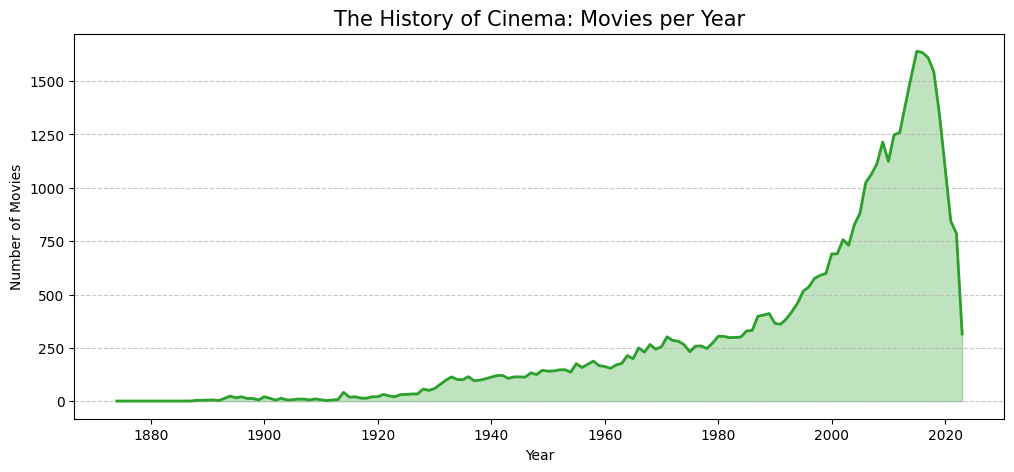

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
# --- VISUAL 1: MOVIE TIMELINE ---
# How many movies were released each year?
plt.figure(figsize=(12, 5))
year_counts = movies_df.filter(pl.col("year") > 0).group_by("year").len().sort("year")
plt.plot(year_counts["year"], year_counts["len"], color='#2ca02c', linewidth=2)
plt.fill_between(year_counts["year"], year_counts["len"], alpha=0.3, color='#2ca02c')
plt.title("The History of Cinema: Movies per Year", fontsize=15)
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("movie_timeline.png")


C:\Users\mhesh\AppData\Local\Temp\ipykernel_7208\2472834855.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="len", y="genres", data=genre_counts.to_pandas(), palette="viridis")


Text(0.5, 0, 'Number of Movies')

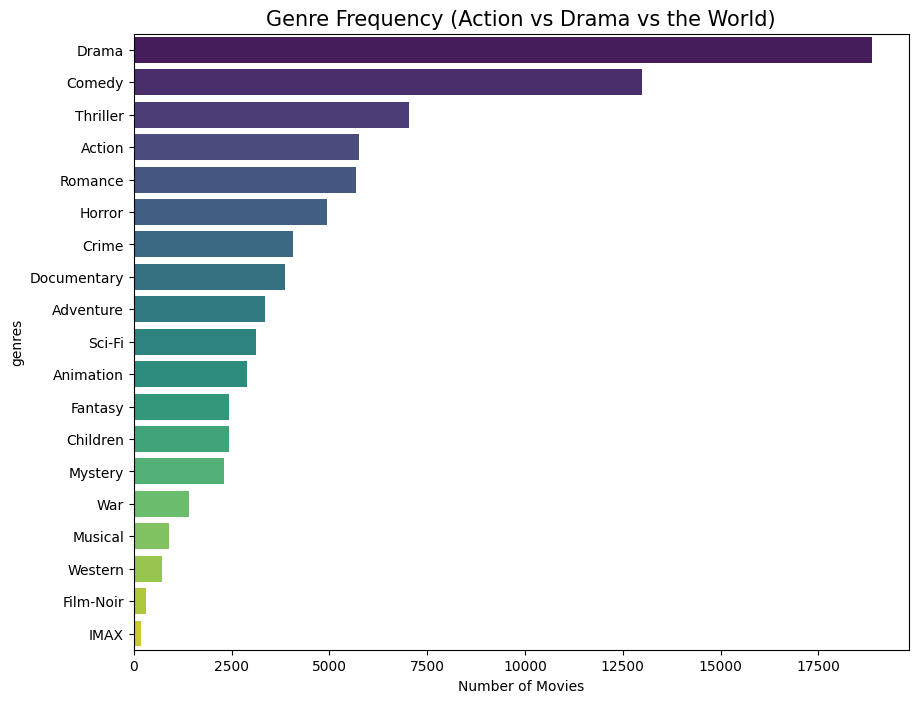

In [61]:
plt.figure(figsize=(10, 8))
genre_counts = (
    movies_df.select("genres")
    .with_columns(pl.col("genres").str.split("|"))
    .explode("genres")
    .filter(pl.col("genres") != "(no genres listed)")
    .group_by("genres")
    .len()
    .sort("len", descending=True)
)
sns.barplot(x="len", y="genres", data=genre_counts.to_pandas(), palette="viridis")
plt.title("Genre Frequency (Action vs Drama vs the World)", fontsize=15)
plt.xlabel("Number of Movies")

C:\Users\mhesh\AppData\Local\Temp\ipykernel_7208\1606383190.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="rating", y="len", data=rating_dist.to_pandas(), palette="coolwarm")


Text(0, 0.5, 'Count of Ratings')

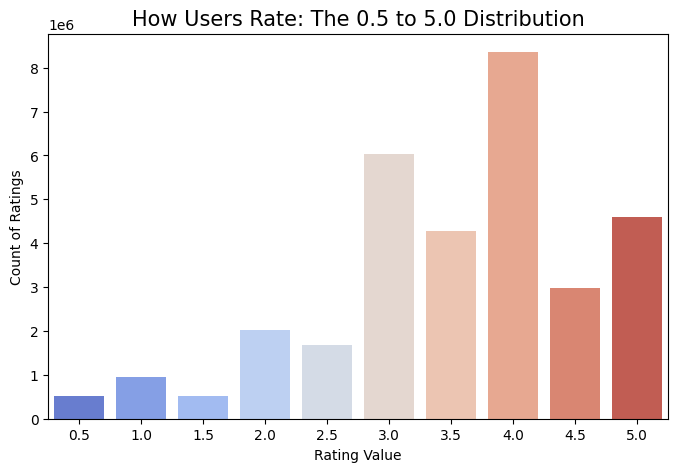

In [62]:
plt.figure(figsize=(8, 5))
rating_dist = ratings_df.group_by("rating").len().sort("rating")
sns.barplot(x="rating", y="len", data=rating_dist.to_pandas(), palette="coolwarm")
plt.title("How Users Rate: The 0.5 to 5.0 Distribution", fontsize=15)
plt.xlabel("Rating Value")
plt.ylabel("Count of Ratings")

C:\Users\mhesh\AppData\Local\Temp\ipykernel_7208\3100640232.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="rating_count", y="display_title", data=top_10.to_pandas(), palette="flare")


Text(0.5, 0, 'Total Number of Ratings')

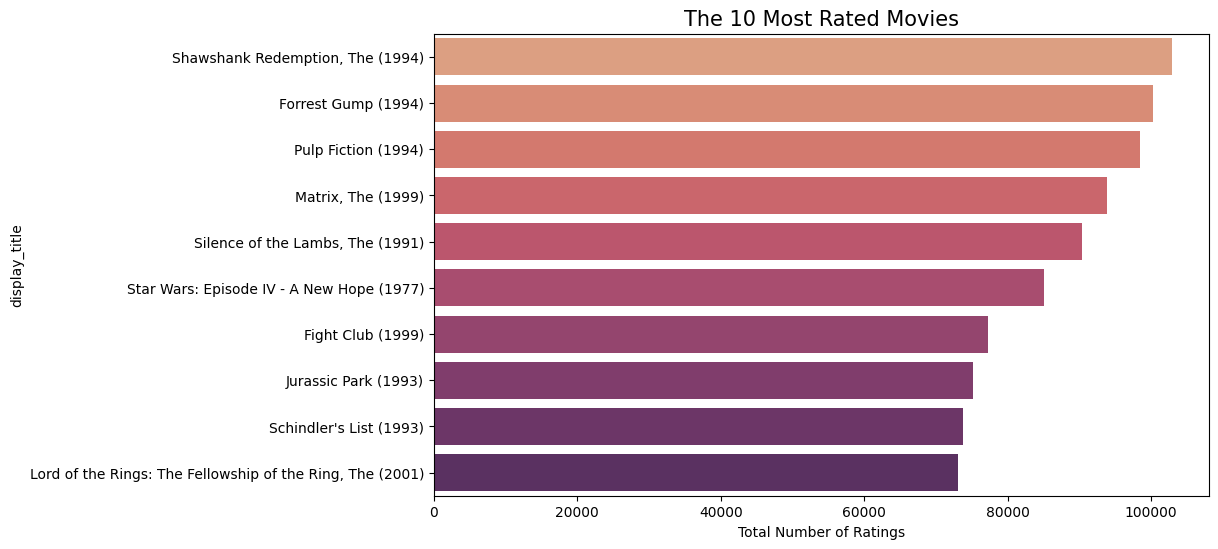

In [63]:
top_10 = (
    movie_stats.join(movies_df, on="movieId")
    .sort("rating_count", descending=True)
    .head(10)
)
plt.figure(figsize=(10, 6))
sns.barplot(x="rating_count", y="display_title", data=top_10.to_pandas(), palette="flare")
plt.title("The 10 Most Rated Movies", fontsize=15)
plt.xlabel("Total Number of Ratings")

In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import scipy.sparse as sp

# --- THE POST-CLEANING PIPELINE ---

# Stage 1: Encode Genres
print("Running Stage 1: Genre Encoding...")
if "tag_right" in movies_final.columns:
    movies_final = movies_final.drop("tag_right")
unique_genres = [g for g in movies_df.select("genres").with_columns(pl.col("genres").str.split("|")).explode("genres").unique().sort("genres")["genres"].to_list() if g != "(no genres listed)"]
for genre in unique_genres:
    col_name = f"g_{genre.lower().replace(' ', '_').replace('-', '_')}"
    movies_df = movies_df.with_columns(pl.col("genres").str.contains(genre).cast(pl.Int8).alias(col_name))

# Stage 2: Scale Year
print("Running Stage 2: Year Scaling...")
min_y, max_y = movies_df.filter(pl.col("year") > 0)["year"].min(), movies_df["year"].max()
movies_df = movies_df.with_columns(((pl.col("year") - min_y) / (max_y - min_y)).clip(0, 1).alias("year_scaled"))

# Stage 3: Vectorize Tags
print("Running Stage 3: Tag Vectorization...")
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_matrix = tfidf.fit_transform(movies_df["tag"].to_list())

# Stage 4: Master Feature Stack
print("Running Stage 4: Feature Stacking...")
feature_cols = [c for c in movies_df.columns if c.startswith("g_") or c == "year_scaled"]
genre_year_matrix = sp.csr_matrix(movies_df.select(feature_cols).to_numpy())
final_features = sp.hstack([genre_year_matrix, tfidf_matrix])

os.makedirs("models", exist_ok=True)
joblib.dump(final_features, "models/final_features.joblib")
movies_final.write_parquet("data/processed/movies_featurized.parquet")
# Stage 5: Inference Function
def get_recommendations(target_title, n=5):
    try:
        idx = movies_df.select(pl.arg_where(pl.col("display_title") == target_title))[0,0]
        query_vec = final_features[idx]
        scores = cosine_similarity(query_vec, final_features).flatten()
        similar_indices = scores.argsort()[-(n+1):-1][::-1]
        return movies_df.with_columns(pl.Series("score", scores)).gather(similar_indices).select(["display_title", "genres", "score"])
    except:
        return "Movie not found. Use the format 'Movie Name (Year)'"

print("\n--- PIPELINE COMPLETE: READY FOR RECOMMENDATIONS ---")

Running Stage 1: Genre Encoding...
Running Stage 2: Year Scaling...
Running Stage 3: Tag Vectorization...
Running Stage 4: Feature Stacking...

--- PIPELINE COMPLETE: READY FOR RECOMMENDATIONS ---


In [65]:
def get_recommendations(target_title, n=5):
    target_title = target_title.strip()
    
    try:
        # 1. Find the index
        idx_series = movies_df.select(pl.arg_where(pl.col("display_title") == target_title))
        
        if idx_series.height == 0:
            return f"❌ '{target_title}' not found."
            
        idx = idx_series[0,0]
        
        # 2. Math: Cosine Similarity
        query_vec = final_features[idx]
        scores = cosine_similarity(query_vec, final_features).flatten()
        
        # 3. Get the top N indices (skipping the first one)
        similar_indices = scores.argsort()[-(n+1):-1][::-1]
        
        # 4. Create the result dataframe (Old-school indexing for compatibility)
        # We add the score and then grab only the similar rows
        temp_df = movies_df.with_columns(pl.Series("score", scores))
        return temp_df[similar_indices, :].select(["display_title", "genres", "score"])
        
    except Exception as e:
        return f"⚠️ An error occurred: {e}"



In [66]:
get_recommendations("Inception (2010)")

display_title,genres,score
str,str,f64
"""Watchmen (2009)""","""Action|Drama|Mystery|Sci-Fi|Th…",0.862261
"""Strange Days (1995)""","""Action|Crime|Drama|Mystery|Sci…",0.847491
"""Third Man Out (2005)""","""Action|Crime|Drama|Mystery|Thr…",0.812563
"""Dying is Easy (2021)""","""Action|Crime|Drama|Mystery|Thr…",0.812313
"""Three Men to Destroy (1980)""","""Action|Crime|Drama|Mystery|Thr…",0.810063


In [68]:
# --- STEP 1: Search for your movie ---
my_search = "Batman"  # <--- CHANGE THIS to any movie name

# This finds the first movie that contains your search term
search_results = movies_df.filter(
    pl.col("display_title").str.contains("(?i)" + my_search) # (?i) makes it case-insensitive
).select("display_title")

if search_results.height > 0:
    target = search_results[0, 0]
    print(f"Targeting: {target}")
    print("-" * 30)
    
    # --- STEP 2: Get Recommendations ---
    recommendations = get_recommendations(target)
    print(recommendations)
else:
    print(f"No movie found containing '{my_search}'. Try a different word!")

Targeting: Batman Forever (1995)
------------------------------
shape: (5, 3)
┌─────────────────────────────────┬───────────────────────────────┬──────────┐
│ display_title                   ┆ genres                        ┆ score    │
│ ---                             ┆ ---                           ┆ ---      │
│ str                             ┆ str                           ┆ f64      │
╞═════════════════════════════════╪═══════════════════════════════╪══════════╡
│ Esa ja Vesa - auringonlaskun r… ┆ Action|Adventure|Comedy|Crime ┆ 0.907358 │
│ Why Me? (1990)                  ┆ Action|Adventure|Comedy|Crime ┆ 0.907266 │
│ Nothing to Lose (1997)          ┆ Action|Adventure|Comedy|Crime ┆ 0.842581 │
│ Kingsman: The Secret Service (… ┆ Action|Adventure|Comedy|Crime ┆ 0.837658 │
│ K-9: P.I. (2002)                ┆ Action|Adventure|Comedy|Crime ┆ 0.832818 │
└─────────────────────────────────┴───────────────────────────────┴──────────┘
